# Preparación del dataset en PyTorch

Este notebook cubre la carga, organización, partición y preprocesamiento del dataset para PyTorch.

**Alcance de esta implementación:**
- Estructura del dataset y análisis de etiquetas.
- Generación de splits reproducibles con `seed` fijo.
- Implementación de un `Dataset` personalizado.
- Creación de `DataLoader` para train / valid / test.
- Preprocesamiento sin data augmentation.
- Verificación de un batch final.

In [1]:
from pathlib import Path
import pandas as pd
import yaml
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import subprocess

ROOT = Path("..")
DATA_ROOT = ROOT / "data"
PROCESSED_ROOT = DATA_ROOT / "processed" / "dataset_no_background"
SPLIT_CSV = {
    "train": DATA_ROOT / "train.csv",
    "valid": DATA_ROOT / "val.csv",
    "test": DATA_ROOT / "test.csv",
}

BATCH_SIZE = 16
NUM_WORKERS = 2
SEED = 42

plt.rcParams["figure.figsize"] = (12, 8)

## 0. Descarga del dataset

Este paso deja el dataset original en `data/raw/` para poder ejecutar el notebook de punta a punta en una máquina nueva.

La descarga se hace solo si la carpeta esperada todavía no existe.

In [ ]:
from pathlib import Path
import subprocess
import sys

RAW_DATASET = DATA_ROOT / "raw"
DOWNLOAD_SCRIPT = ROOT / "dowload_dataset.py"


def raw_dataset_is_ready(raw_root: Path) -> bool:
    required_paths = [
        raw_root / "train",
        raw_root / "valid",
        raw_root / "test",
        raw_root / "data.yaml",
    ]
    return all(path.exists() for path in required_paths)


if raw_dataset_is_ready(RAW_DATASET):
    print(f"El dataset ya existe en: {RAW_DATASET.resolve()}")
else:
    if not DOWNLOAD_SCRIPT.exists():
        raise FileNotFoundError(f"No se encontró el script de descarga: {DOWNLOAD_SCRIPT.resolve()}")

    print(f"Descargando dataset con: {DOWNLOAD_SCRIPT.resolve()}")
    subprocess.run([sys.executable, str(DOWNLOAD_SCRIPT)], check=True)
    print(f"Descarga finalizada en: {RAW_DATASET.resolve()}")

Descargando dataset con: C:\Users\emili\OneDrive - alumnos.frm.utn.edu.ar\Documentos\Facultad\5to año\Redes Neuronales\Integrador\code\RedesNeuronales\dowload_dataset.py
Descarga finalizada en: C:\Users\emili\OneDrive - alumnos.frm.utn.edu.ar\Documentos\Facultad\5to año\Redes Neuronales\Integrador\code\RedesNeuronales\data\raw


## 0. Eliminación de fondo y creación de `data/processed`

Esta celda procesa el dataset original en `data/raw/dataset/`, elimina el fondo blanco de cada imagen y guarda el resultado en `data/processed/dataset_no_background/`.

In [6]:
import cv2
import shutil
import random
from pathlib import Path
from tqdm import tqdm

RAW_DATASET = DATA_ROOT / "raw"
PROCESSED_DATASET = PROCESSED_ROOT

WHITE_THRESHOLD = 240
MORPH_KERNEL_SIZE = 3
VALID_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".webp"}
 
# Split configuration (change ratios and set REGENERATE_SPLITS=True to force new partitioning)
TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1
REGENERATE_SPLITS = True


def remove_white_background(img_bgr: np.ndarray, threshold: int = WHITE_THRESHOLD, kernel_size: int = MORPH_KERNEL_SIZE) -> np.ndarray:
    h, w = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    white_mask = (np.all(img_rgb >= threshold, axis=2).astype(np.uint8) * 255)

    flood_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)
    flood_img = white_mask.copy()
    corners = [(0, 0), (0, w - 1), (h - 1, 0), (h - 1, w - 1)]

    for fy, fx in corners:
        if white_mask[fy, fx] == 255:
            cv2.floodFill(
                flood_img,
                flood_mask,
                (fx, fy),
                128,
                loDiff=10,
                upDiff=10,
                flags=cv2.FLOODFILL_FIXED_RANGE,
            )

    bg_mask = (flood_img == 128).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    bg_mask = cv2.morphologyEx(bg_mask, cv2.MORPH_CLOSE, kernel)
    bg_mask = cv2.morphologyEx(bg_mask, cv2.MORPH_DILATE, kernel)

    alpha = cv2.bitwise_not(bg_mask)
    alpha = cv2.GaussianBlur(alpha, (3, 3), 0)
    _, alpha = cv2.threshold(alpha, 10, 255, cv2.THRESH_BINARY)

    b, g, r = cv2.split(img_bgr)
    img_bgra = cv2.merge([b, g, r, alpha])
    return img_bgra


def _discover_image_label_dirs(root: Path):
    """Try to locate images/ and labels/ directories under root or its first child."""
    images = root / "images"
    labels = root / "labels"
    if images.exists() and labels.exists():
        return images, labels

    # look for a single child that contains images/ and labels/
    for child in root.iterdir():
        if child.is_dir() and (child / "images").exists() and (child / "labels").exists():
            return child / "images", child / "labels"

    # fallback: search recursively for any images folder
    for p in root.rglob("images"):
        if (p.parent / "labels").exists():
            return p, p.parent / "labels"

    return None, None


def create_stratified_splits(raw_dataset: Path, seed: int = SEED, train_ratio: float = TRAIN_RATIO, val_ratio: float = VAL_RATIO, test_ratio: float = TEST_RATIO, force: bool = False):
    """Create train/valid/test folders under raw_dataset with stratified sampling by the first class in label files.

    Handles cases where `raw_dataset` already contains `train/valid/test` by first collecting
    all image/label pairs and moving the original split folders to a temporary backup when
    `force=True`, so regeneration does not try to copy from directories that will be removed.
    """
    random.seed(seed)

    # Collect all image/label pairs. If the root already contains train/valid/test, gather from them.
    existing_splits = [d for d in ["train", "valid", "test"] if (raw_dataset / d).exists()]

    all_items = []
    if existing_splits:
        for s in existing_splits:
            images_dir = raw_dataset / s / "images"
            labels_dir = raw_dataset / s / "labels"
            if images_dir.exists() and labels_dir.exists():
                for p in sorted(images_dir.iterdir()):
                    if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS:
                        all_items.append((p, labels_dir / f"{p.stem}.txt"))
    else:
        images_dir, labels_dir = _discover_image_label_dirs(raw_dataset)
        if images_dir is None or labels_dir is None:
            raise FileNotFoundError(f"No se encontraron carpetas 'images' y 'labels' bajo {raw_dataset}")
        for p in sorted(images_dir.iterdir()):
            if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS:
                all_items.append((p, labels_dir / f"{p.stem}.txt"))

    if not all_items:
        raise FileNotFoundError(f"No se encontraron imágenes en {raw_dataset}")

    # If existing splits will be removed and force=True, move them to a backup to keep sources available.
    backup_dir = None
    if existing_splits and force:
        backup_dir = raw_dataset / "_split_source_backup"
        if backup_dir.exists():
            shutil.rmtree(backup_dir)
        backup_dir.mkdir(parents=True, exist_ok=True)
        for s in existing_splits:
            src = raw_dataset / s
            dst = backup_dir / s
            src.replace(dst)
        # adjust all_items to point to backup paths
        new_all_items = []
        for p, lbl in all_items:
            rel = p.relative_to(raw_dataset)
            new_p = backup_dir / rel
            rel_lbl = lbl.relative_to(raw_dataset)
            new_lbl = backup_dir / rel_lbl
            new_all_items.append((new_p, new_lbl))
        all_items = new_all_items

    # Group by class
    records_by_class = {}
    unlabeled = []
    for img, lbl in all_items:
        cls = None
        if lbl.exists():
            txt = lbl.read_text().strip()
            if txt:
                try:
                    cls = int(txt.split()[0])
                except Exception:
                    cls = None
        if cls is None:
            unlabeled.append((img, lbl))
        else:
            records_by_class.setdefault(cls, []).append((img, lbl))

    train_items, val_items, test_items = [], [], []

    for cls, items in records_by_class.items():
        random.shuffle(items)
        n = len(items)
        n_train = int(round(n * train_ratio))
        n_val = int(round(n * val_ratio))
        n_val = min(n_val, n - n_train)
        n_test = n - n_train - n_val
        train_items.extend(items[:n_train])
        val_items.extend(items[n_train:n_train + n_val])
        test_items.extend(items[n_train + n_val:])

    unlabeled_shuffled = unlabeled.copy()
    random.shuffle(unlabeled_shuffled)
    n_un = len(unlabeled_shuffled)
    n_train_un = int(round(n_un * train_ratio))
    n_val_un = int(round(n_un * val_ratio))
    n_val_un = min(n_val_un, n_un - n_train_un)
    train_items.extend(unlabeled_shuffled[:n_train_un])
    val_items.extend(unlabeled_shuffled[n_train_un:n_train_un + n_val_un])
    test_items.extend(unlabeled_shuffled[n_train_un + n_val_un:])

    def _write_split(split_name, items):
        out_images = raw_dataset / split_name / "images"
        out_labels = raw_dataset / split_name / "labels"
        out_images.mkdir(parents=True, exist_ok=True)
        out_labels.mkdir(parents=True, exist_ok=True)
        for img_path, label_path in items:
            shutil.copy2(img_path, out_images / img_path.name)
            if label_path.exists():
                shutil.copy2(label_path, out_labels / label_path.name)

    print(f"Creando particiones estratificadas (seed={seed}): train={len(train_items)}, valid={len(val_items)}, test={len(test_items)}")

    # If existing splits remain (and not moved), handle removal if force True
    for s in ["train", "valid", "test"]:
        sdir = raw_dataset / s
        if sdir.exists() and any(sdir.iterdir()):
            if force and backup_dir is None:
                print(f"Nota: la carpeta {sdir} ya existe y contiene archivos. Se sobrescribirá porque 'force=True'.")
                shutil.rmtree(sdir)
            elif not force:
                print(f"La carpeta {sdir} ya existe. Use 'force=True' para regenerar. Saltando regeneración.")
                return

    _write_split("train", train_items)
    _write_split("valid", val_items)
    _write_split("test", test_items)

    # write CSVs
    try:
        import pandas as _pd

        def _rel_paths_for(items, split_name):
            rows = []
            for img_path, label_path in items:
                stem = img_path.stem
                rows.append({"image": f"{split_name}/images/{stem}.png", "label": f"{split_name}/labels/{stem}.txt"})
            return rows

        train_rows = _rel_paths_for(train_items, "train")
        val_rows = _rel_paths_for(val_items, "valid")
        test_rows = _rel_paths_for(test_items, "test")

        if train_rows:
            _pd.DataFrame(train_rows).to_csv(DATA_ROOT / "train.csv", index=False)
        if val_rows:
            _pd.DataFrame(val_rows).to_csv(DATA_ROOT / "val.csv", index=False)
        if test_rows:
            _pd.DataFrame(test_rows).to_csv(DATA_ROOT / "test.csv", index=False)

        print(f"CSV de splits escritos en {DATA_ROOT} (train/val/test).")
    except Exception as e:
        print(f"Advertencia: no se pudieron escribir los CSV de splits: {e}")

    # cleanup backup if present
    if backup_dir and backup_dir.exists():
        try:
            shutil.rmtree(backup_dir)
        except Exception:
            pass


def process_dataset(raw_dataset: Path, processed_dataset: Path):
    if not raw_dataset.exists():
        raise FileNotFoundError(f"No existe el dataset raw: {raw_dataset.resolve()}")

    splits = ["train", "valid", "test"]
    total_images = 0

    for split in splits:
        input_images = raw_dataset / split / "images"
        input_labels = raw_dataset / split / "labels"
        output_images = processed_dataset / split / "images"
        output_labels = processed_dataset / split / "labels"

        output_images.mkdir(parents=True, exist_ok=True)
        output_labels.mkdir(parents=True, exist_ok=True)

        image_paths = [
            p for p in sorted(input_images.iterdir())
            if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
        ]

        print(f"\n[{split.upper()}] {len(image_paths)} imágenes encontradas")

        for img_path in tqdm(image_paths, desc=f"Procesando {split}"):
            img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
            if img_bgr is None:
                print(f"No se pudo leer: {img_path.name}")
                continue

            img_bgra = remove_white_background(img_bgr)
            out_img = output_images / f"{img_path.stem}.png"
            cv2.imwrite(str(out_img), img_bgra)

            label_file = input_labels / f"{img_path.stem}.txt"
            if label_file.exists():
                shutil.copy2(label_file, output_labels / label_file.name)
            total_images += 1

    yaml_file = raw_dataset / "data.yaml"
    if yaml_file.exists():
        processed_dataset.mkdir(parents=True, exist_ok=True)
        shutil.copy2(yaml_file, processed_dataset / "data.yaml")

    print("\nProcesamiento completado.")
    print(f"Imágenes procesadas: {total_images}")
    print(f"Salida: {processed_dataset.resolve()}")


if RAW_DATASET.exists():
    # if splits are missing or user requested regeneration, generate stratified splits
    splits_missing = not (RAW_DATASET / "train").exists() or not (RAW_DATASET / "valid").exists() or not (RAW_DATASET / "test").exists()
    if splits_missing or REGENERATE_SPLITS:
        print("Generando particiones estratificadas (force regeneration=" + str(REGENERATE_SPLITS) + ")...")
        create_stratified_splits(RAW_DATASET, seed=SEED, force=REGENERATE_SPLITS)
    process_dataset(RAW_DATASET, PROCESSED_DATASET)
else:
    print(f"No existe la carpeta raw dataset: {RAW_DATASET.resolve()}")

Generando particiones estratificadas (force regeneration=True)...
Creando particiones estratificadas (seed=42): train=813, valid=232, test=115
CSV de splits escritos en ..\data (train/val/test).

[TRAIN] 813 imágenes encontradas


Procesando train: 100%|██████████| 813/813 [01:31<00:00,  8.88it/s]



[VALID] 232 imágenes encontradas


Procesando valid: 100%|██████████| 232/232 [00:26<00:00,  8.87it/s]



[TEST] 115 imágenes encontradas


Procesando test: 100%|██████████| 115/115 [00:12<00:00,  8.91it/s]


Procesamiento completado.
Imágenes procesadas: 1160
Salida: C:\Users\emili\OneDrive - alumnos.frm.utn.edu.ar\Documentos\Facultad\5to año\Redes Neuronales\Integrador\code\RedesNeuronales\data\processed\dataset_no_background


## 1. Estructura del dataset

El dataset procesado está en `data/processed/dataset_no_background/` y conserva la estructura YOLO original:

- `train/images/`
- `train/labels/`
- `valid/images/`
- `valid/labels/`
- `test/images/`
- `test/labels/`

Las etiquetas son archivos `.txt` con formato YOLO: `class x_center y_center width height` en coordenadas normalizadas.

Para PyTorch implementaremos un dataset personalizado porque la estructura no es compatible con `ImageFolder`.

In [7]:
print("Processed dataset root:", PROCESSED_ROOT.resolve())
print("Exists:", PROCESSED_ROOT.exists())
print("Split CSV files:")
for split, path in SPLIT_CSV.items():
    print(f"  {split}: {path.relative_to(ROOT)} -> {path.exists()}")

yaml_path = PROCESSED_ROOT / "data.yaml"
if yaml_path.exists():
    with open(yaml_path, "r", encoding="utf-8") as f:
        yaml_data = yaml.safe_load(f)
    print("\nclasses:", yaml_data.get("names"))
    print("nc:", yaml_data.get("nc"))
else:
    print("No se encontró data.yaml en el dataset procesado.")

Processed dataset root: C:\Users\emili\OneDrive - alumnos.frm.utn.edu.ar\Documentos\Facultad\5to año\Redes Neuronales\Integrador\code\RedesNeuronales\data\processed\dataset_no_background
Exists: True
Split CSV files:
  train: data\train.csv -> True
  valid: data\val.csv -> True
  test: data\test.csv -> True

classes: ['Bearish Engulfing', 'Bearish Insidebar', 'Bullish Engulfing', 'Bullish Insidebar', 'Hammer', 'Inverted_Hammer']
nc: 6


## 3. Dataset personalizado de PyTorch

Usamos un `Dataset` que:
- carga cada imagen desde `data/processed/dataset_no_background/...`
- convierte RGBA a RGB si es necesario
- lee la etiqueta clase desde el archivo `.txt`
- aplica transformaciones de preprocesamiento

In [8]:
CLASS_NAMES = yaml_data.get("names", [])
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

base_transforms = T.Compose([
    T.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_transforms = T.Compose([
    T.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def read_yolo_class(label_path: Path) -> int:
    text = label_path.read_text().strip()
    if not text:
        raise ValueError(f"Etiqueta vacía en {label_path}")
    return int(text.split()[0])


class CandlestickDataset(Dataset):
    def __init__(self, csv_path: Path, dataset_root: Path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.dataset_root = dataset_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = self.dataset_root / row["image"]
        label_path = self.dataset_root / row["label"]

        image = Image.open(image_path)
        label = read_yolo_class(label_path)

        if self.transform is not None:
            image = self.transform(image)

        return image, label


train_dataset = CandlestickDataset(SPLIT_CSV["train"], PROCESSED_ROOT, transform=train_transforms)
valid_dataset = CandlestickDataset(SPLIT_CSV["valid"], PROCESSED_ROOT, transform=base_transforms)
test_dataset = CandlestickDataset(SPLIT_CSV["test"], PROCESSED_ROOT, transform=base_transforms)

print("Train samples:", len(train_dataset))
print("Valid samples:", len(valid_dataset))
print("Test samples:", len(test_dataset))

Train samples: 813
Valid samples: 232
Test samples: 115


## Data augmentation (solo train)

Aplicamos `ColorJitter` solo al conjunto de entrenamiento para simular variaciones de iluminacion y color sin alterar la estructura de las velas. En validacion y test se usa el preprocesamiento base sin augmentations.

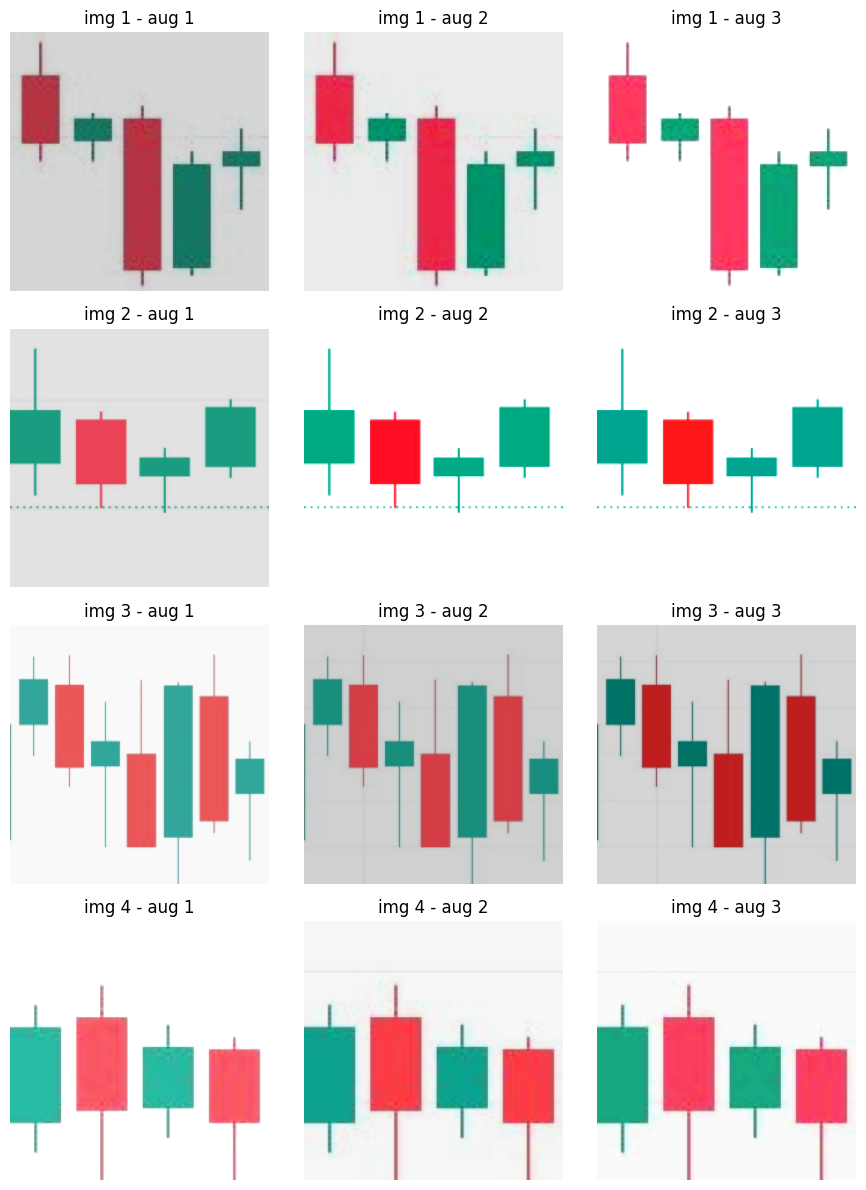

In [11]:
from torchvision.transforms import functional as TF

NUM_IMAGES = 4
AUGS_PER_IMAGE = 3

preview_transform = T.Compose([
    T.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
])

train_df = pd.read_csv(SPLIT_CSV["train"])
preview_rows = train_df.head(NUM_IMAGES)

fig, axes = plt.subplots(NUM_IMAGES, AUGS_PER_IMAGE, figsize=(AUGS_PER_IMAGE * 3, NUM_IMAGES * 3))
if NUM_IMAGES == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, (_, row) in enumerate(preview_rows.iterrows()):
    image_path = PROCESSED_ROOT / row["image"]
    image = Image.open(image_path)

    for aug_idx in range(AUGS_PER_IMAGE):
        aug_img = preview_transform(image)
        ax = axes[row_idx, aug_idx]
        ax.imshow(aug_img)
        ax.set_axis_off()
        ax.set_title(f"img {row_idx + 1} - aug {aug_idx + 1}")

plt.tight_layout()
plt.show()

In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

batch = next(iter(train_loader))
images, labels = batch
print("Batch images shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Image range before denorm: min=", images.min().item(), "max=", images.max().item())

c:\Users\emili\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:431: UserWarning: Got pickle error when attempting to start a worker Process. This might be because the worker Process arguments are not picklable. Python 3.14+ changed the multiprocessing start method in non-Mac POSIX platforms to 'forkserver', which requires the worker Process arguments to be picklable. You can also try multiprocessing.set_start_method('fork').
  return _MultiProcessingDataLoaderIter(self)


PicklingError: Can't pickle <function <lambda> at 0x00000192B95EF2E0>: attribute lookup <lambda> on __main__ failed

In [ ]:
unnormalize = T.Normalize(
    mean=[-m / s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1 / s for s in IMAGENET_STD]
)

sample_images = images[:8]
sample_labels = labels[:8]

image_grid = make_grid(unnormalize(sample_images), nrow=4, padding=2)
image_grid = image_grid.permute(1, 2, 0).numpy()
image_grid = np.clip(image_grid, 0, 1)

plt.figure(figsize=(14, 8))
plt.imshow(image_grid)
plt.axis("off")
plt.title("Batch de imágenes de train desnormalizadas")
plt.show()

print("Etiquetas del batch:", sample_labels.tolist())
print("Clases de ejemplo:", [CLASS_NAMES[l] if l < len(CLASS_NAMES) else str(l) for l in sample_labels.tolist()])